## Workflow


We create  a VQE- circuit for to calculate the ground state energy of the following $N$-site spin-1/2 topology on four qubits:

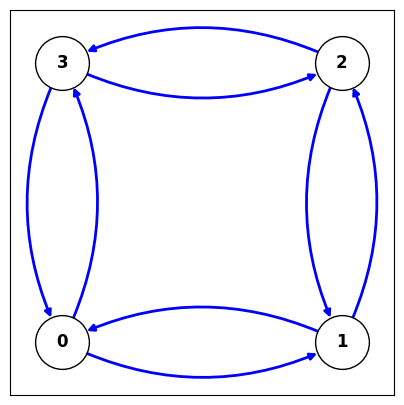

In [1]:
import sys; sys.path.append('../..')
import numpy as np
from src.plot_helpers import plot_topology

topology = np.array([[0, 0], [1, 0], [1, 1], [0, 1]])

ax = plot_topology(topology)

In [2]:
from src.VQE_functions import optimize_energy, MFIM_Hamiltonian, build_hva_layers
from qiskit.transpiler import CouplingMap
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit_ibm_runtime.fake_provider import FakeWashingtonV2
from scipy.linalg import eigh
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel

hx = 1
hz = 1
J = -1

Hamiltonian = MFIM_Hamiltonian(J=J, hx=hx, hz=hz, topology = topology)
hva_layers, params = build_hva_layers(topology=topology, num_layers=1)

# FakeBackend laden
fake_backend = FakeWashingtonV2()
noise_model = NoiseModel.from_backend(fake_backend)
backend_noisy = AerSimulator(noise_model=noise_model)

backend = AerSimulator()

num_layers = 1
initial_params = [1,1,1]
bounds = [(-np.pi, np.pi)] * 3*num_layers

opt_params, energy, HelperInfo = optimize_energy(initial_params=initial_params, Hamiltonian=Hamiltonian, topology=topology, num_layers=num_layers, backend=backend, mode="measurement",bounds = bounds)

values = {p: v for p, v in zip(params, opt_params)}
qc_bound = hva_layers.assign_parameters(values)
print(qc_bound.draw(fold=-1))

exact_energy = np.min(eigh(Hamiltonian.to_matrix(), eigvals_only=True))

print("Measured energy: ",energy)
print("Relative error: ", np.abs(energy - exact_energy) / np.abs(exact_energy) *100, "%")
print("initial parameters: ",initial_params)
print("optimale Parameter: ", opt_params)

Optimierung startet...
Optimierung fertig.
     ┌───┐┌─────────────┐┌────────────┐                                                                      
q_0: ┤ H ├┤ Rz(-1.6596) ├┤ Rx(1.3064) ├──■───────────────────■────■──────────────────────────────────■───────
     ├───┤├─────────────┤├────────────┤┌─┴─┐┌─────────────┐┌─┴─┐  │                                  │       
q_1: ┤ H ├┤ Rz(-1.6596) ├┤ Rx(1.3064) ├┤ X ├┤ Rz(0.74163) ├┤ X ├──┼─────────■────────────────────────┼────■──
     ├───┤├─────────────┤├────────────┤└───┘└─────────────┘└───┘  │       ┌─┴─┐     ┌─────────────┐  │  ┌─┴─┐
q_2: ┤ H ├┤ Rz(-1.6596) ├┤ Rx(1.3064) ├──■───────────────────■────┼───────┤ X ├─────┤ Rz(0.74163) ├──┼──┤ X ├
     ├───┤├─────────────┤├────────────┤┌─┴─┐┌─────────────┐┌─┴─┐┌─┴─┐┌────┴───┴────┐└─────────────┘┌─┴─┐└───┘
q_3: ┤ H ├┤ Rz(-1.6596) ├┤ Rx(1.3064) ├┤ X ├┤ Rz(0.74163) ├┤ X ├┤ X ├┤ Rz(0.74163) ├───────────────┤ X ├─────
     └───┘└─────────────┘└────────────┘└───┘└─────────────┘└───┘└───┘└───────

Backend aussuchen

In [3]:
from qiskit.transpiler import CouplingMap
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit_ibm_runtime.fake_provider import FakeWashingtonV2
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel


# FakeBackend mit Noise laden
fake_backend = FakeWashingtonV2()
noise_model = NoiseModel.from_backend(fake_backend)
backend_noisy = AerSimulator(noise_model=noise_model)

phys_qubits = [0,1,2,3]

# FakeBackend ohne Noise laden
coupling = CouplingMap(couplinglist=[(0, 1), (1, 2), (2, 3)])
backend = GenericBackendV2(num_qubits=4, coupling_map=coupling)
#backend = AerSimulator() Alternative

Ressourcen checken

In [4]:
from src.calculate_runs import count_tomography_runs, count_per_runs

# TOMOGRAPHY
res_tomo = count_tomography_runs(
    qc=qc_bound,
    backend=backend,
    phys_qubits=phys_qubits,
    depths=[2,4,16,32,64],
    samples=100,
    single_samples=250,
    shots=1024   # optional
)
print("Tomography: ",res_tomo['backend_runs'])

# PER
res_per = count_per_runs(
    qc=qc_bound,
    pauli_list=[p.to_label() for p in Hamiltonian.paulis],
    noise_strengths=[0,1,2],
    samples=1000,
    shots=1024   # optional
)
print("PER: ",res_per['backend_runs'])
print("Total: ",res_per['backend_runs'] + res_tomo['backend_runs'])

=== Tomography ===
Circuits:       12000
Backend runs:  12288000
Details:
  N_layers        : 2
  num_meas_bases  : 9
  depth_count     : 5
  samples         : 100
  single_samples  : 250
  sum_single_bases: 12
Tomography:  12288000

=== PER ===
Circuits:       6000
Backend runs:  6144000
Details:
  num_meas_bases_per : 2
  num_noise_strengths: 3
  samples            : 1000
PER:  6144000
Total:  18432000


# Run Experiment

In [ ]:
from pauli_lindblad_per.tomography.experiment import SparsePauliTomographyExperiment as tomography

experiment = tomography(
    circuits = [qc_bound], #list of circuits from which to get the layers requiring tomography
    backend = backend, #quantum backend
    phys_qubits=phys_qubits # physical Qubits on which all operations will be performed
    )

experiment.generate(
    samples = 50, #Number of samples to take from the fidelity pair measurements
    single_samples = 100, #samples to take from the pair-breaking measurements
    depths = [2,4,8] #values of 2n to make the pair measurements. Numbers must be even and non-zero
    )

shots = 1024
def executor(circuits):
    return backend.run(circuits, shots = shots, noise_model=noise_model).result().get_counts()

#run the experiment
experiment.run(executor)
noisedataframe = experiment.analyze()